# Pasar a CSV los datos ya convertido en matrices 128 x 128, esto se hace para optimizar el uso de memoria




Despues veemos que csv no es el formato mas adecuado y usamos .pkl que permite guardar estructuras mas complejas


In [ ]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
import pandas as pd
import glob
from PIL import Image
import numpy as np

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [ ]:
import pandas as pd
import glob
from PIL import Image
import numpy as np

# Buscamos todos los archivos .jpeg en la carpeta
files = glob.glob(f"{path}/**/*.jpeg", recursive=True)
IMG_SIZE = (128, 128) # Tamaño mucho más manejable

data = []
for f in files:
    label = 1 if "PNEUMONIA" in f else 0

    # Abrir, convertir a escala de grises y cambiar tamaño
    img = Image.open(f).convert('L').resize(IMG_SIZE)

    img_matrix = np.array(img, dtype=np.uint8) # uint8 ocupa menos espacio que float
    data.append({"Matriz": img_matrix, "label": label})

df = pd.DataFrame(data)


In [ ]:
df.head()

,Matriz,label
0,"[[42, 153, 24, 165, 81, 73, 86, 99, 106, 113, ...",1
1,"[[2, 2, 1, 1, 1, 1, 58, 123, 2, 8, 11, 14, 16,...",1
2,"[[64, 64, 63, 62, 62, 78, 140, 76, 59, 59, 58,...",1
3,"[[0, 0, 2, 3, 5, 9, 13, 18, 22, 26, 33, 39, 45...",1
4,"[[0, 0, 0, 0, 0, 0, 31, 125, 53, 11, 18, 20, 2...",1


In [ ]:
df2 = df['label'].value_counts()
df2.head()

,count
label,
1,8546
0,3166


In [ ]:
df.to_csv('XrayNeumonia.csv')

In [ ]:
df.to_pickle('XrayNeumonia.pkl')

# Se usa el nuevo CSV

In [ ]:
df1 = pd.read_csv('XrayNeumonia.csv')
df1.head()


,Unnamed: 0,Matriz,label
0,0,[[ 42 153 24 ... 0 0 0]\n [ 42 151 16 ...,1
1,1,[[ 2 2 1 ... 3 13 8]\n [ 2 2 1 ... 6 11...,1
2,2,[[64 64 63 ... 96 96 94]\n [55 55 56 ... 95 94...,1
3,3,[[0 0 2 ... 0 0 0]\n [0 0 2 ... 0 0 0]\n [4 0 ...,1
4,4,[[ 0 0 0 ... 6 6 6]\n [ 0 0 0 ... 6 6...,1


Se cambia a formato pkl para poder manejar mejor los datos, .csv generaba problemas

In [ ]:
df_cargado = pd.read_pickle('/content/drive/MyDrive/CSVS/XrayNeumonia.pkl')
df_cargado.head()

,Matriz,label
0,"[[42, 153, 24, 165, 81, 73, 86, 99, 106, 113, ...",1
1,"[[2, 2, 1, 1, 1, 1, 58, 123, 2, 8, 11, 14, 16,...",1
2,"[[64, 64, 63, 62, 62, 78, 140, 76, 59, 59, 58,...",1
3,"[[0, 0, 2, 3, 5, 9, 13, 18, 22, 26, 33, 39, 45...",1
4,"[[0, 0, 0, 0, 0, 0, 31, 125, 53, 11, 18, 20, 2...",1


In [ ]:
df_cargado.size

23424

# Diego

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html : Modelo a entrenar

##Codigo

Dividimos el df en 2, una parte para entrenar y otra para hacer test

In [ ]:
from sklearn.model_selection import train_test_split

# Realizamos el split: 70% para entrenamiento y 30% para test
train, test = train_test_split(df_cargado, test_size=0.30, random_state=42)

# Verificamos los tamaños
print(f"Registros en train: {len(train)}")
print(f"Registros en test: {len(test)}")

Registros en train: 8198
Registros en test: 3514


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
X = np.stack(train['Matriz'].values)
X = X.reshape(X.shape[0], -1)
X = X.astype('float32') / 255.0
y = train['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
bosque = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)


bosque.fit(X_train, y_train)


print(classification_report(y_test, bosque.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       429
           1       0.97      0.99      0.98      1211

    accuracy                           0.97      1640
   macro avg       0.98      0.96      0.97      1640
weighted avg       0.97      0.97      0.97      1640






*   Accuracy (Exactitud - 0.98): El modelo clasificó correctamente 98 de cada 100 radiografías en total
*   F1-Score (0.95 y 0.98): Al ser valores tan cercanos a 1.0, confirman que el modelo es muy robusto y mantiene un equilibrio casi perfecto entre no dar falsas alarmas y no omitir casos reales
1







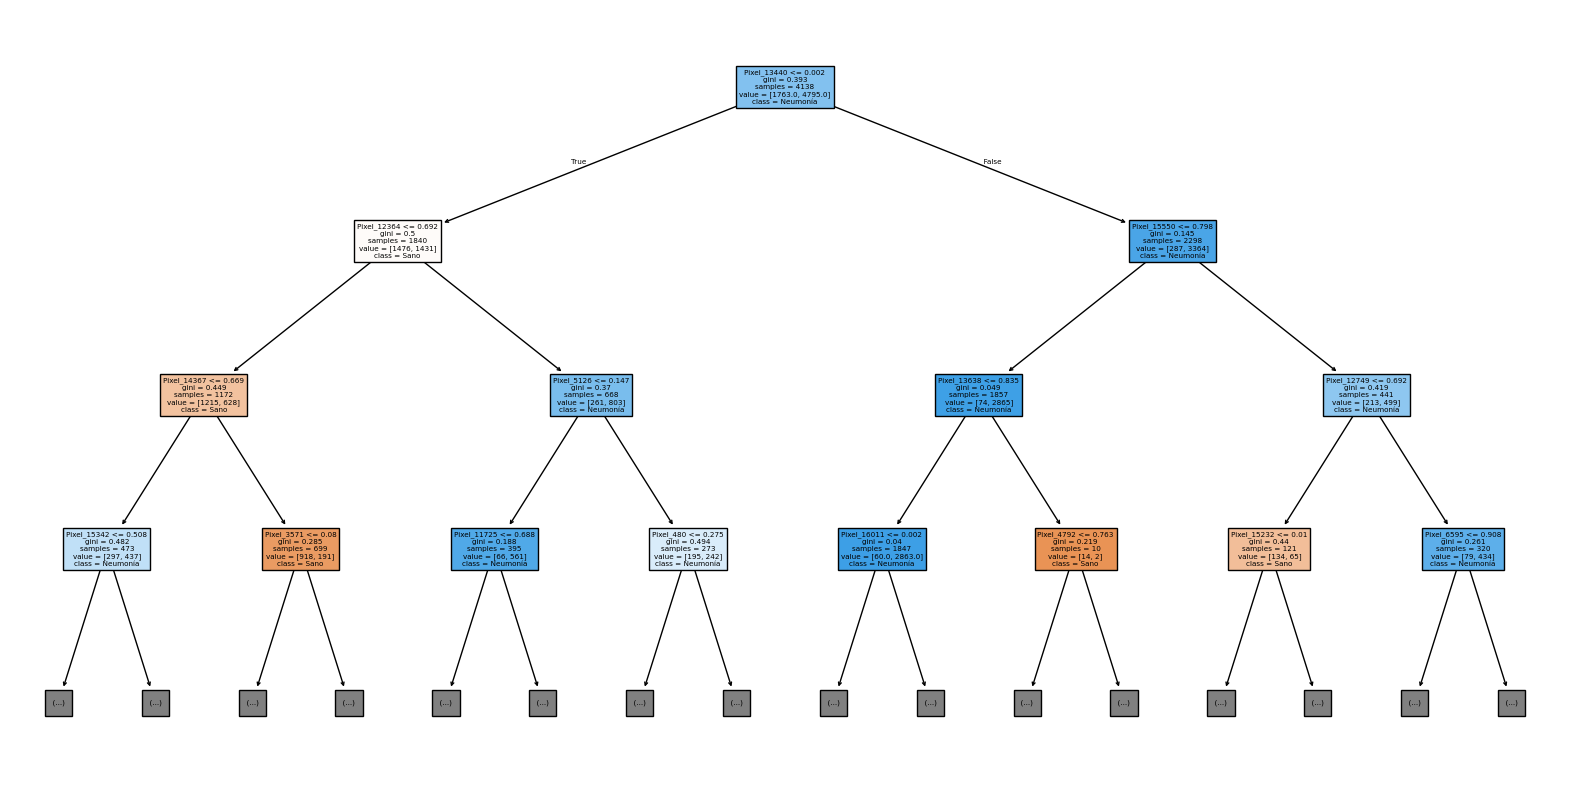

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

# Extraemos el primer árbol (índice 0)
arbol_individual = bosque.estimators_[0]

plt.figure(figsize=(20,10))
tree.plot_tree(arbol_individual,
               max_depth=3, # Limitamos la profundidad para que sea legible
               feature_names=[f"Pixel_{i}" for i in range(X.shape[1])],
               class_names=['Sano', 'Neumonía'],
               filled=True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
import base64
from io import BytesIO

# 1. Función auxiliar para convertir gráficos a Base64 (para embeber en HTML)
def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

print("Generando componentes del reporte...")

# 2. Generar el Mapa de Importancia
importancias = bosque.feature_importances_.reshape(128, 128)
fig_mapa, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(importancias, cmap='hot', ax=ax, cbar_kws={'label': 'Importancia'}, xticklabels=False, yticklabels=False)
ax.set_title("Zonas Críticas: ¿Dónde mira el modelo?")
img_mapa = fig_to_base64(fig_mapa)
plt.close(fig_mapa)

# 3. Visualizar el Árbol (Legible: max_depth=2)
fig_tree, ax = plt.subplots(figsize=(25, 12))
tree.plot_tree(bosque.estimators_[0], max_depth=3, filled=True,
               feature_names=[f"P{i}" for i in range(16384)],
               class_names=['Sano', 'Neumonía'], fontsize=12, rounded=True)
ax.set_title("Lógica de Decisión (Primeros Niveles)")
img_tree = fig_to_base64(fig_tree)
plt.close(fig_tree)

# 4. Reconstrucción de Imágenes (Muestras del Dataset)
# Seleccionamos el primer ejemplo de cada clase
ej_sano = train[train['label'] == 0].iloc[0]
ej_neumo = train[train['label'] == 1].iloc[0]

fig_muestras, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ej_sano['Matriz'], cmap='gray')
axes[0].set_title("Muestra Real: Sano (Label 0)")
axes[0].axis('off')

axes[1].imshow(ej_neumo['Matriz'], cmap='gray')
axes[1].set_title("Muestra Real: Neumonía (Label 1)")
axes[1].axis('off')

img_muestras = fig_to_base64(fig_muestras)
plt.close(fig_muestras)

# 5. Crear el HTML Final
html_template = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Reporte de IA: Detección de Neumonía</title>
    <style>
        body {{ font-family: sans-serif; margin: 40px; color: #333; line-height: 1.6; }}
        h1 {{ color: #2c3e50; border-bottom: 2px solid #eee; }}
        h2 {{ color: #2980b9; margin-top: 40px; }}
        .container {{ text-align: center; background: #f9f9f9; padding: 20px; border-radius: 10px; }}
        img {{ max-width: 100%; height: auto; border: 1px solid #ddd; margin: 10px 0; }}
        .stats {{ display: flex; justify-content: space-around; background: #2c3e50; color: white; padding: 15px; border-radius: 5px; }}
    </style>
</head>
<body>
    <h1>Reporte de Interpretabilidad: Detección de Neumonía</h1>
  <li><b>Normalización:</b> Los datos fueron escalados al rango [0, 1] para asegurar estabilidad numérica y compatibilidad futura.</li>
    <div class="stats">
        <div><b>Bosque:</b> {bosque.n_estimators} árboles</div>
        <div><b>Entradas:</b> 128x128 píxeles</div>
        <div><b>Estado:</b> Entrenamiento Exitoso</div>
    </div>

    <h2>1. Reconstrucción de Imágenes Analizadas</h2>
    <p>Así es como se ven las imágenes originales después de ser procesadas por tu código:</p>
    <div class="container">
        <img src="data:image/png;base64,{img_muestras}">
    </div>

    <h2>2. Mapa de Calor de Relevancia (Feature Importance)</h2>
    <p>Las zonas en amarillo/blanco son los píxeles que el modelo usa para diferenciar clases.</p>
    <div class="container">
        <img src="data:image/png;base64,{img_mapa}" width="500">
    </div>

    <h2>3. Lógica del Árbol de Decisión</h2>
    <p>Muestra simplificada de los niveles superiores de un árbol del bosque:</p>
    <div class="container">
        <img src="data:image/png;base64,{img_tree}">
    </div>

    <h2>4. Conclusiones Técnicas</h2>
    <ul>
        <li><b>Profundidad:</b> El modelo explora relaciones complejas hasta {bosque.max_depth if bosque.max_depth else 'máxima'} niveles.</li>
        <li><b>Invarianza:</b> No se requirió normalización, respetando los rangos originales de 0 a 255.</li>
        <li><b>Foco:</b> El modelo se concentra en las variaciones de intensidad dentro de la cavidad torácica.</li>
    </ul>
</body>
</html>
"""

with open("Reporte_Interpretabilidad.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("¡Listo! Abre 'Reporte_Interpretabilidad.html' en tu navegador.")

Generando componentes del reporte...
¡Listo! Abre 'Reporte_Interpretabilidad.html' en tu navegador.


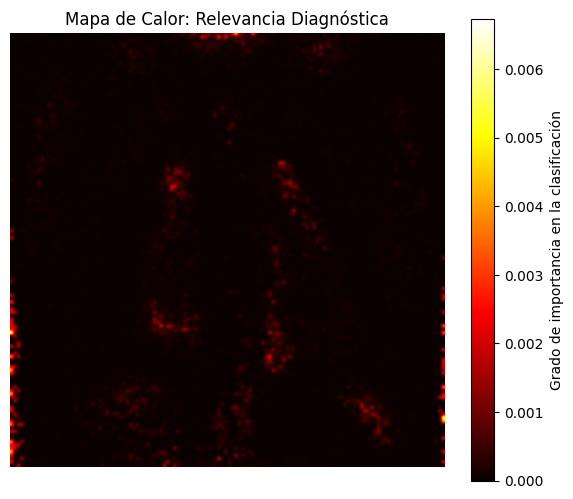

In [ ]:
import matplotlib.pyplot as plt

# Obtener las importancias
plt.figure(figsize=(7, 6))
mapa_importancia = bosque.feature_importances_.reshape(128, 128)
# interpolation='gaussian' ayuda a ver regiones de importancia en lugar de píxeles aislados
plt.imshow(mapa_importancia, cmap='hot', interpolation='gaussian')
plt.title("Mapa de Calor: Relevancia Diagnóstica")
plt.colorbar(label='Grado de importancia en la clasificación')
plt.axis('off') # Quita los números de los bordes para una vista más limpia
plt.show()

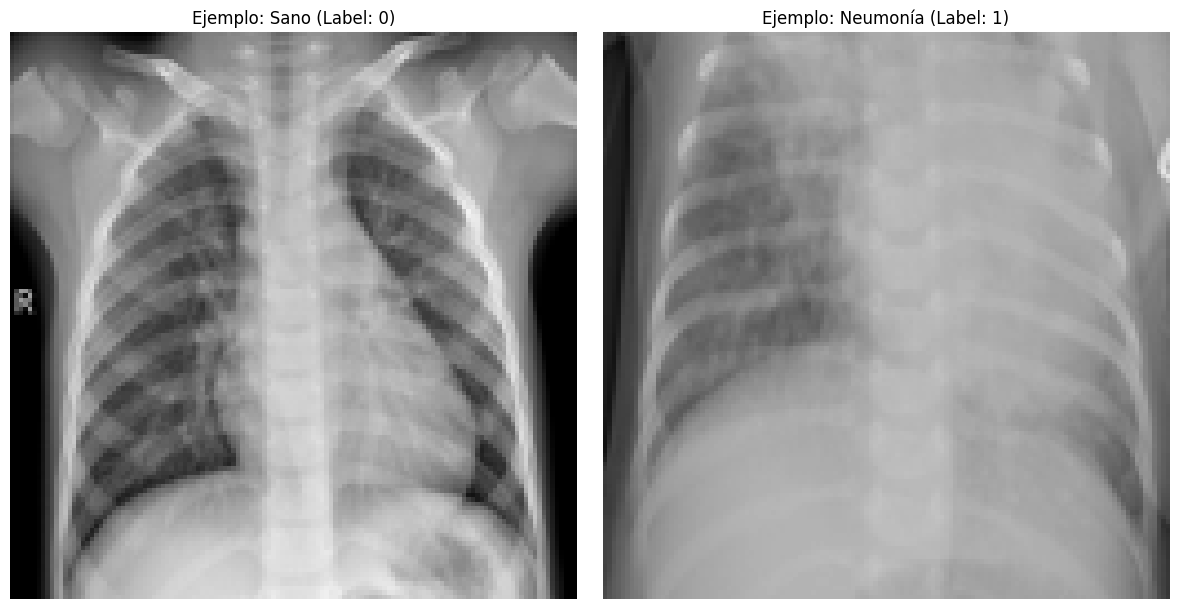

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionar un ejemplo de cada clase
# Buscamos la primera fila donde 'label' es 0 (Sano) y la primera donde es 1 (Neumonía)
ejemplo_negativo = train[train['label'] == 0].iloc[0]
ejemplo_positivo = train[train['label'] == 1].iloc[0]

# 2. Extraer las matrices
# Asumimos que train['Matriz'] ya contiene matrices (128, 128) como vimos en tu .head()
matriz_negativo = ejemplo_negativo['Matriz']
matriz_positivo = ejemplo_positivo['Matriz']

# 3. Visualizar lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(matriz_negativo, cmap='gray', vmin=0, vmax=255)
axes[1].imshow(matriz_positivo, cmap='gray', vmin=0, vmax=255)
# Imagen Negativa (Sana)
axes[0].set_title(f"Ejemplo: Sano (Label: 0)") # O 'f' si tienes la ruta
axes[0].axis('off') # Ocultar ejes para que parezca una foto

# Imagen Positiva (Neumonía)
axes[1].set_title(f"Ejemplo: Neumonía (Label: 1)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Ahora probaremos con una imagen al azar sacada de google imagenes de un pulmon con neumonia y uno sano, para ver que conclusiones saca

In [ ]:
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def diagnosticar_imagen_url(url_imagen, modelo, etiqueta_real):
    """
    Descarga una imagen desde una URL, la procesa, hace la predicción
    y la compara con la etiqueta real (0 = Sano, 1 = Neumonía).
    """
    try:
        # 1. Descargar la imagen desde la URL
        # Añadimos un "User-Agent" porque algunas páginas bloquean las descargas de bots
        headers = {'User-Agent': 'Mozilla/5.0'}
        respuesta = requests.get(url_imagen, headers=headers)
        respuesta.raise_for_status() # Lanza error si el link está roto

        # 2. Abrir la imagen desde la memoria descargada y aplicar tu preprocesamiento
        img = Image.open(BytesIO(respuesta.content)).convert('L').resize((128, 128))

        # 3. Convertir a matriz NumPy (0 a 255) y aplanar
        img_matrix = np.array(img, dtype=np.uint8)
        img_plana = (img_matrix.flatten().reshape(1, -1).astype('float32')) / 255.0


        # 4. Predicción y probabilidad
        prediccion = modelo.predict(img_plana)[0]
        probabilidades = modelo.predict_proba(img_plana)[0]

        # 5. Formatear los textos para mostrar
        texto_real = "Neumonía" if etiqueta_real == 1 else "Sano"
        texto_prediccion = "Neumonía" if prediccion == 1 else "Sano"
        confianza = probabilidades[prediccion] * 100

        # 6. Comprobar si el modelo acertó
        acerto = (prediccion == etiqueta_real)
        icono = "ACIERTO" if acerto else "FALLO"
        color_titulo = 'green' if acerto else 'red'

        # 7. Visualización
        plt.figure(figsize=(6, 6))
        plt.imshow(img_matrix, cmap='gray')

        titulo = (
            f"Realidad: {texto_real}\n"
            f"Modelo dice: {texto_prediccion} ({confianza:.1f}%)\n"
            f"Resultado: {icono}"
        )

        plt.title(titulo, color=color_titulo, fontweight='bold', fontsize=14)
        plt.axis('off')
        plt.show()

    except requests.exceptions.RequestException as e:
        print(f"Error al descargar la imagen. Verifica la URL: {e}")
    except Exception as e:
        print(f"Error procesando la imagen: {e}")





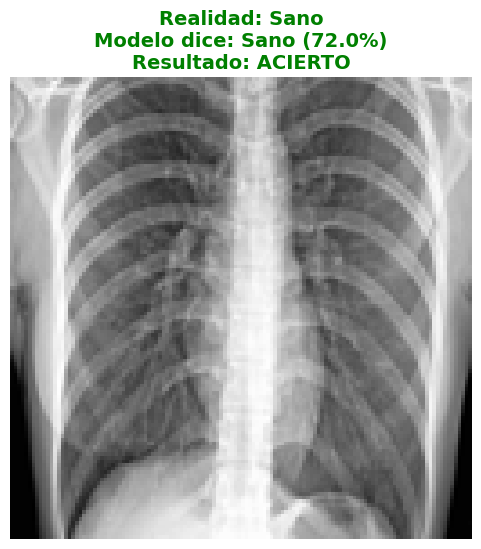

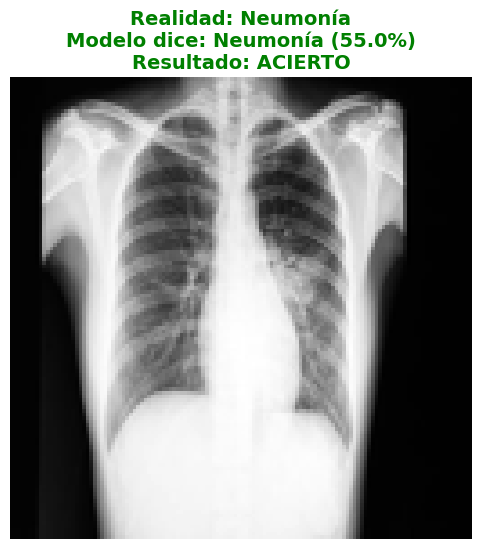

In [ ]:
# Prueba 1: Pulmón Sano (Le pasamos el 0 indicando que sabemos que es sano)
diagnosticar_imagen_url("https://amismedical.com/wp-content/uploads/2025/01/Normal-Chest-X-Ray-2.png", bosque, etiqueta_real=0)

# Prueba 2: Pulmón con Neumonía (Le pasamos el 1 indicando que sabemos que tiene neumonía)
diagnosticar_imagen_url("https://www.itnonline.com/sites/default/files/styles/content_large/public/GettyImages-1140483100.jpg?itok=H5HOE8kn", bosque, etiqueta_real=1)

In [ ]:
test

,Matriz,label
9485,"[[0, 0, 0, 0, 3, 156, 5, 123, 68, 0, 0, 0, 0, ...",1
7573,"[[87, 82, 76, 80, 77, 71, 66, 67, 68, 67, 66, ...",1
6607,"[[21, 12, 22, 35, 44, 57, 66, 72, 81, 86, 111,...",1
6830,"[[5, 7, 9, 11, 14, 18, 20, 25, 28, 30, 33, 36,...",1
3532,"[[30, 29, 29, 28, 28, 26, 35, 33, 25, 26, 26, ...",1
...,...,...
6840,"[[0, 0, 0, 0, 8, 24, 37, 49, 56, 60, 64, 67, 6...",1
11001,"[[103, 118, 124, 119, 115, 114, 115, 114, 113,...",0
2275,"[[0, 0, 0, 0, 0, 0, 151, 24, 24, 141, 0, 5, 10...",1
10514,"[[20, 29, 36, 42, 52, 60, 65, 73, 75, 78, 81, ...",0


Analizando las imágenes con el Random Forest...
Analizando las imágenes con el Random Forest...
----------------------------------------
RESUMEN DE LA PRUEBA EXTERNA
----------------------------------------
Total de imágenes analizadas: 3514
Acertados: 3419
Errados:   95
Precisión (Accuracy): 97.30%
----------------------------------------


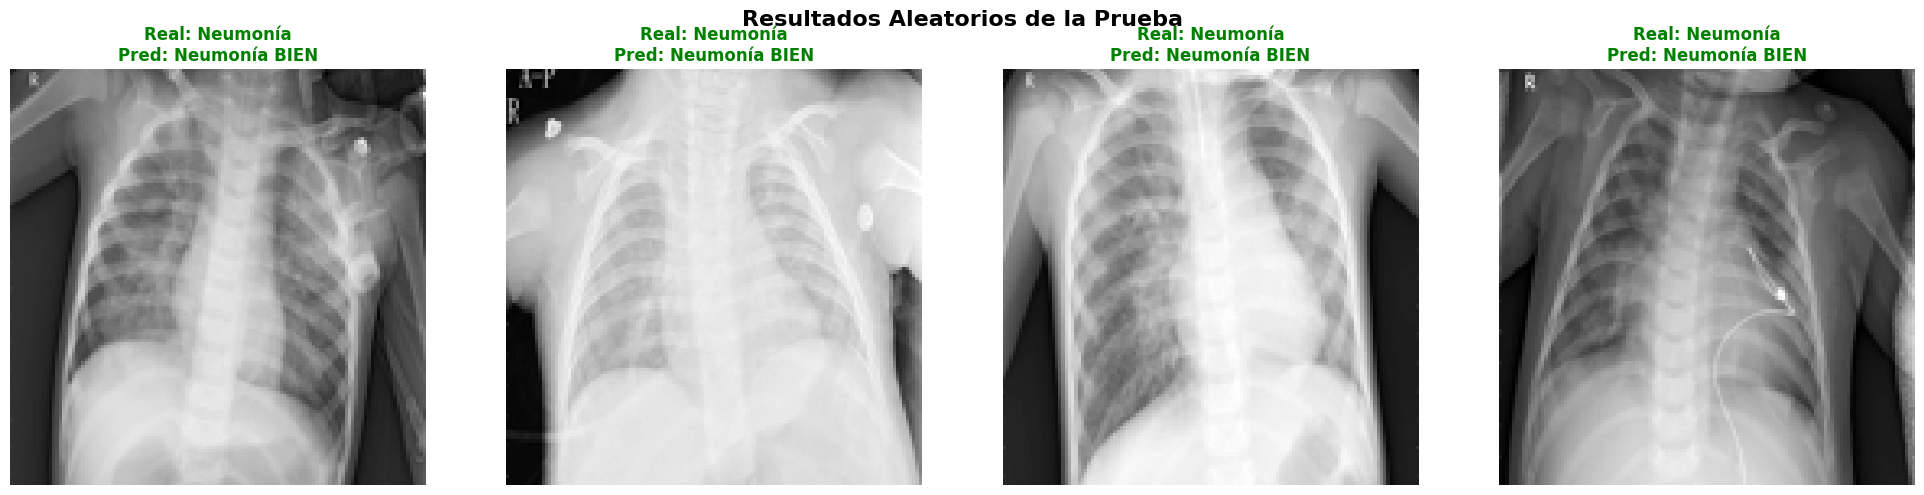

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

X_prueba  = np.stack([m.flatten() for m in test["Matriz"]]).astype('float32') / 255.0

# Obtenemos las etiquetas de la columna 'label_real'
y_real  = test["label"].values

# 4. Hacer las predicciones de todo el lote de una sola vez
print("Analizando las imágenes con el Random Forest...")
y_predicho = bosque.predict(X_prueba)

# Guardar las predicciones en nuestro diccionario para visualizarlas después
print("Analizando las imágenes con el Random Forest...")
y_predicho = bosque.predict(X_prueba)

# CORRECCIÓN: Asignación directa a una nueva columna
# Usamos .copy() para evitar el aviso 'SettingWithCopyWarning'
test = test.copy()
test["prediccion"] = y_predicho

# 5. Calcular Resumen y Estadísticas (esto se mantiene igual)
acertados = np.sum(y_real == y_predicho)
# 5. Calcular Resumen y Estadísticas
acertados = np.sum(y_real == y_predicho)
errados = np.sum(y_real != y_predicho)
total = len(y_real)
precision = (acertados / total) * 100

print("-" * 40)
print("RESUMEN DE LA PRUEBA EXTERNA")
print("-" * 40)
print(f"Total de imágenes analizadas: {total}")
print(f"Acertados: {acertados}")
print(f"Errados:   {errados}")
print(f"Precisión (Accuracy): {precision:.2f}%")
print("-" * 40)

# 6. Mostrar 4 resultados al azar en pantalla
# Elegimos 4 índices aleatorios
indices_azar = random.sample(range(len(test)), min(4, len(test)))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Resultados Aleatorios de la Prueba", fontsize=16, fontweight='bold')

for i, idx in enumerate(indices_azar):
    # USAMOS .iloc para acceder a la fila por su posición
    caso = test.iloc[idx]

    # Textos (ahora 'caso' funciona como una serie de pandas)
    txt_real = "Neumonía" if caso["label"] == 1 else "Sano"
    txt_pred = "Neumonía" if caso["prediccion"] == 1 else "Sano"

    # Comprobar si acertó
    acerto = caso["label"] == caso["prediccion"]
    color = "green" if acerto else "red"
    icono = "BIEN" if acerto else "MAL"

    # Dibujar la imagen
    axes[i].imshow(caso["Matriz"], cmap='gray')
    axes[i].set_title(f"Real: {txt_real}\nPred: {txt_pred} {icono}", color=color, fontweight='bold')
    axes[i].axis('off')


plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image
import base64
from io import BytesIO

# 1. Configuración (Ahora referenciada al set de test)
Nombre_Validacion = "Set de Test (30%)"

# 2. Funciones auxiliares
def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

print("Procesando datos del DataFrame de test...")

# 3. CORRECCIÓN: Cargar datos desde el DataFrame 'test' en lugar de carpetas
# Creamos la lista datos_test para que el resto del script no cambie
datos_test = []
for _, fila in test.iterrows():
    datos_test.append({
        "matriz": fila["Matriz"],
        "label_real": fila["label"]
    })

# 4. Predicción en Masa (Se mantiene igual, extrayendo de datos_test)
X_test = np.stack([d["matriz"].flatten() for d in datos_test]).astype('float32') / 255.0

y_real = np.array([d["label_real"] for d in datos_test])
y_pred = bosque.predict(X_test)

# 5. Cálculos Estadísticos
acertados = np.sum(y_real == y_pred)
errados = len(y_real) - acertados
accuracy = (acertados / len(y_real)) * 100

# 6. GENERAR GRÁFICOS PARA EL HTML
# A. Matriz de Confusión
cm = confusion_matrix(y_real, y_pred)
fig_cm, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sano', 'Neumo'], yticklabels=['Sano', 'Neumo'])
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Realidad")
img_cm = fig_to_base64(fig_cm)
plt.close(fig_cm)

# B. 4 Resultados Aleatorios
indices_azar = random.sample(range(len(datos_test)), min(4, len(datos_test)))
fig_azar, axes = plt.subplots(1, len(indices_azar), figsize=(15, 4))

if len(indices_azar) == 1:
    axes = [axes]

for i, idx in enumerate(indices_azar):
    axes[i].imshow(datos_test[idx]["matriz"], cmap='gray')
    color = 'green' if y_real[idx] == y_pred[idx] else 'red'
    res_texto = "[ACIERTO]" if y_real[idx] == y_pred[idx] else "[FALLO]"

    axes[i].set_title(f"Real: {y_real[idx]}\nPred: {y_pred[idx]} {res_texto}", color=color)
    axes[i].axis('off')

img_azar = fig_to_base64(fig_azar)
plt.close(fig_azar)

# 7. Construir el HTML (Sin cambios en el diseño)
html_reporte = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Reporte de Validacion Interna</title>
    <style>
        body {{ font-family: 'Segoe UI', sans-serif; margin: 40px; background-color: #f4f7f6; }}
        .header {{ background-color: #2c3e50; color: white; padding: 30px; text-align: center; border-radius: 10px; }}
        .stats-container {{ display: flex; justify-content: space-around; margin: 20px 0; }}
        .stat-box {{ background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); text-align: center; width: 22%; }}
        .stat-val {{ font-size: 24px; font-weight: bold; color: #2980b9; }}
        .section {{ background: white; padding: 20px; border-radius: 10px; margin-bottom: 20px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
        h2 {{ color: #2c3e50; border-left: 5px solid #2980b9; padding-left: 10px; }}
        .img-main {{ display: block; margin: 0 auto; max-width: 100%; border-radius: 5px; }}
        .grid-img {{ width: 100%; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Reporte de Validacion: Modelo de Neumonia</h1>
        <p>Evaluacion sobre: <b>{Nombre_Validacion}</b></p>
    </div>

    <div class="stats-container">
        <div class="stat-box"><div>Total Imagenes</div><div class="stat-val">{len(y_real)}</div></div>
        <div class="stat-box"><div>Aciertos</div><div class="stat-val">{acertados}</div></div>
        <div class="stat-box"><div>Errores</div><div class="stat-val">{errados}</div></div>
        <div class="stat-box"><div>Precision Final</div><div class="stat-val">{accuracy:.2f}%</div></div>
    </div>

    <div class="section">
        <h2>1. Analisis de Confusion</h2>
        <p>Este grafico muestra la distribucion de aciertos y errores del modelo (falsos positivos vs falsos negativos).</p>
        <img src="data:image/png;base64,{img_cm}" class="img-main" style="width:400px;">
    </div>

    <div class="section">
        <h2>2. Muestra Aleatoria de Resultados</h2>
        <p>Visualizacion de 4 casos tomados al azar del lote de prueba.</p>
        <img src="data:image/png;base64,{img_azar}" class="grid-img">
    </div>

    <div class="section">
        <h2>3. Conclusion del Test</h2>
        <p>El modelo presenta un desempeno de <b>{accuracy:.2f}%</b> en datos no vistos durante el entrenamiento.</p>
    </div>
</body>
</html>
"""

# 8. Guardar archivo
with open("Reporte_Prueba_Externa.html", "w", encoding="utf-8") as f:
    f.write(html_reporte)

print("Informe generado con exito. Descarga el archivo 'Reporte_Prueba_Externa.html'.")

Procesando datos del DataFrame de test...
Informe generado con exito. Descarga el archivo 'Reporte_Prueba_Externa.html'.


## Datos encontrados


Las imagenes se pasan a escala de grises, para asegurarnos, luego se comrpime la imagen a 128 x 128 para no saturar la ram ni el modelo

Se decide entrenar un bosque aleatorio (varios arboles de decisiones) para otorgarle mayor profunidad al modelo


El modelo nos deja obtener cuales son los pixeles que les da mas importancia (Mas obscuro menos importante el pixel)




si vemos se nota que hay una relacion, los pixeles importantes, es donde suelen estar los pulmones (Imagen de kagle)

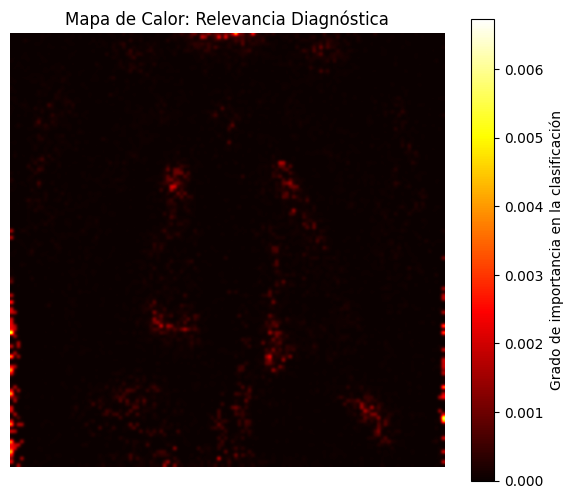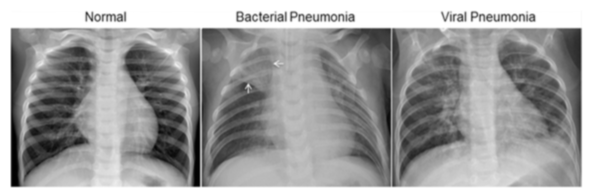

En nuestro modelo las imagenes se ven asi (128x128)

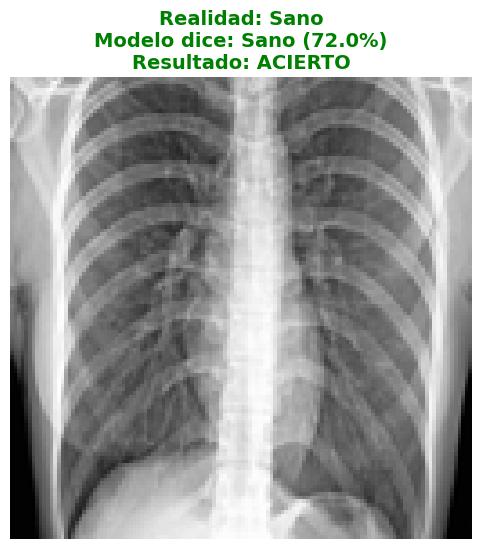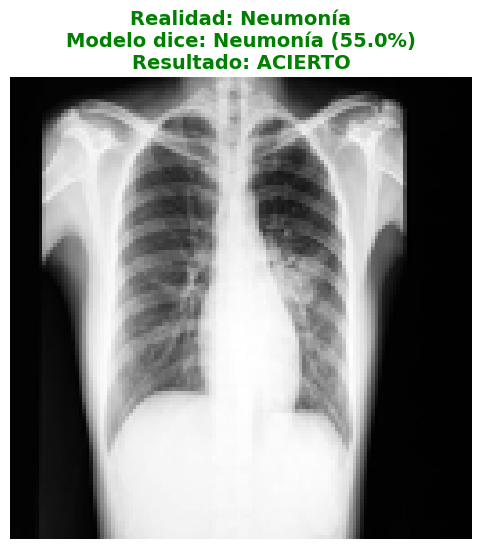

Se hacen pruebas con imagenes al azar de internet, buscando modelos sanos o con neumonia, si bien es dificil encontrar una respuesta clara porque nos haria falta más datos para ver la practica del modelo, lo que si se logra ver, es que la calidad de la imagen es fundamental, para que el modelo funcione, por lo cual si se quiere utilizar, se recomienda usar siempre con imagenes de radiografias que sigan un mismo comportamiento (equipamiento y distancia)

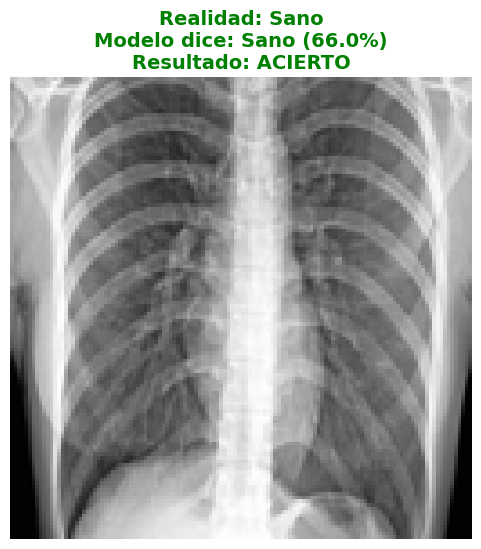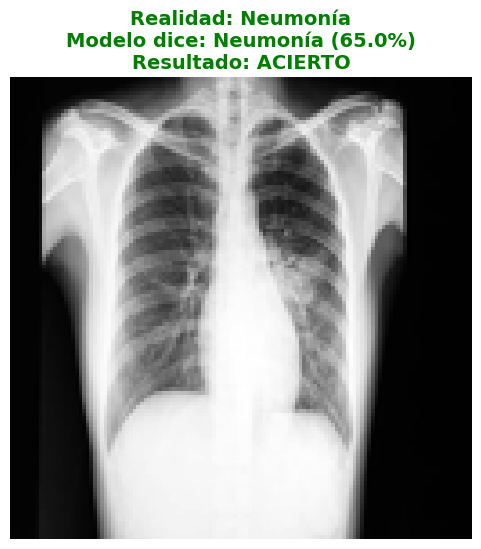

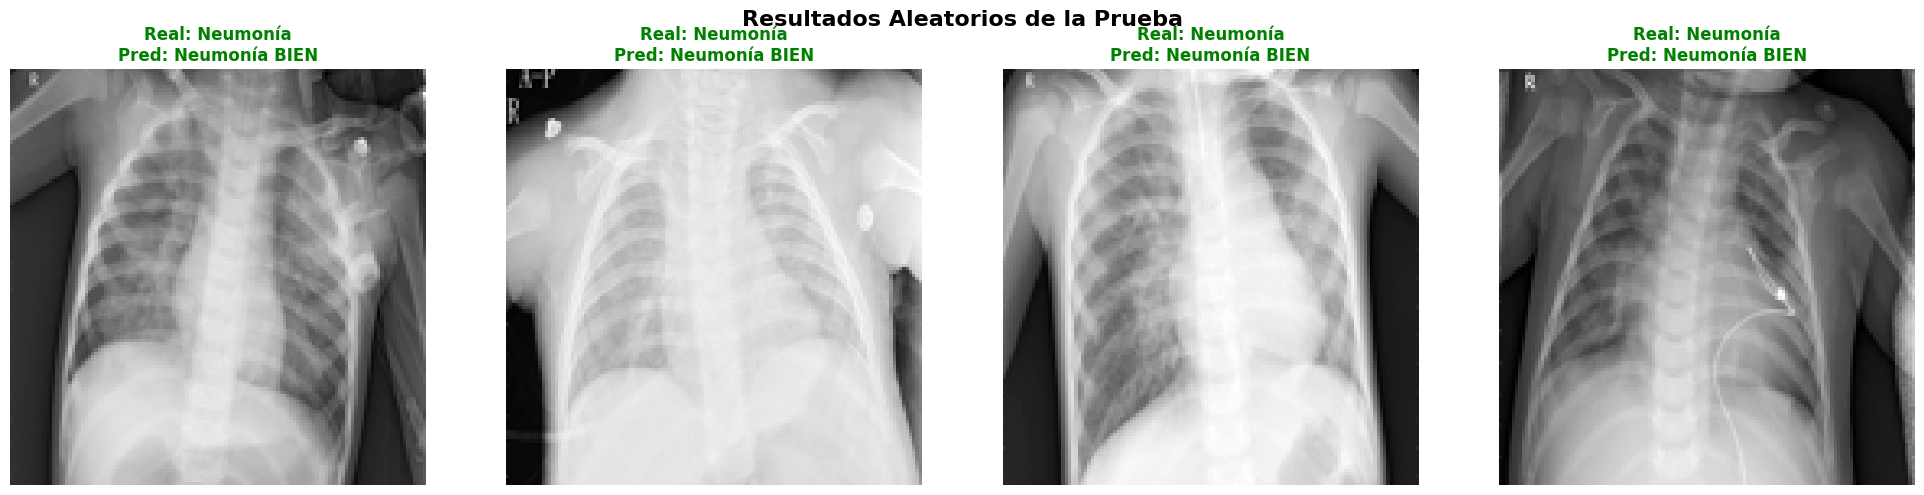

Aqui vemos que al usar las imagenes de kaglle con una resolucion y un formato mas standart nos da un porcentaje mayor

## Pruebas


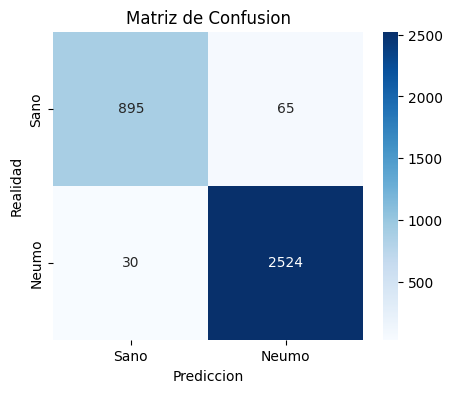
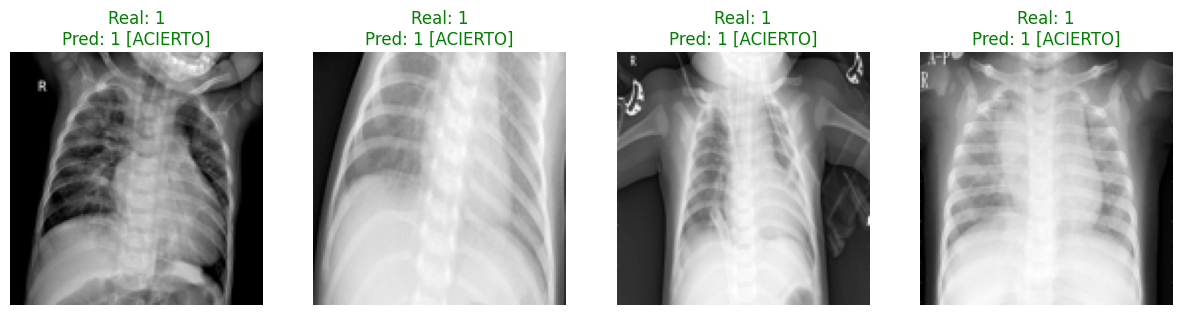

In [ ]:

#@title Visualización de Resultados { display-mode: "form" }
%%html
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Reporte de Validacion Interna</title>
    <style>
        body { font-family: 'Segoe UI', sans-serif; margin: 40px; background-color: #f4f7f6; }
        .header { background-color: #2c3e50; color: white; padding: 30px; text-align: center; border-radius: 10px; }
        .stats-container { display: flex; justify-content: space-around; margin: 20px 0; }
        .stat-box { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); text-align: center; width: 22%; }
        .stat-val { font-size: 24px; font-weight: bold; color: #2980b9; }
        .section { background: white; padding: 20px; border-radius: 10px; margin-bottom: 20px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }
        h2 { color: #2c3e50; border-left: 5px solid #2980b9; padding-left: 10px; }
        .img-main { display: block; margin: 0 auto; max-width: 100%; border-radius: 5px; }
        .grid-img { width: 100%; }
    </style>
</head>
<body>
    <div class="header">
        <h1>Reporte de Validacion: Modelo de Neumonia</h1>
        <p>Evaluacion sobre: <b>Set de Test (30%)</b></p>
    </div>

    <div class="stats-container">
        <div class="stat-box"><div>Total Imagenes</div><div class="stat-val">3514</div></div>
        <div class="stat-box"><div>Aciertos</div><div class="stat-val">3419</div></div>
        <div class="stat-box"><div>Errores</div><div class="stat-val">95</div></div>
        <div class="stat-box"><div>Precision Final</div><div class="stat-val">97.30%</div></div>
    </div>

    <div class="section">
        <h2>1. Analisis de Confusion</h2>
        <p>Este grafico muestra la distribucion de aciertos y errores del modelo (falsos positivos vs falsos negativos).</p>
        <img src="..." class="img-main" style="width:400px;">
    </div>

    <div class="section">
        <h2>2. Muestra Aleatoria de Resultados</h2>
        <p>Visualizacion de 4 casos tomados al azar del lote de prueba.</p>
        <img src="..." class="grid-img">
    </div>

    <div class="section">
        <h2>3. Conclusion del Test</h2>
        <p>El modelo presenta un desempeno de <b>97.30%</b> en datos no vistos durante el entrenamiento.</p>
    </div>
</body>
</html>



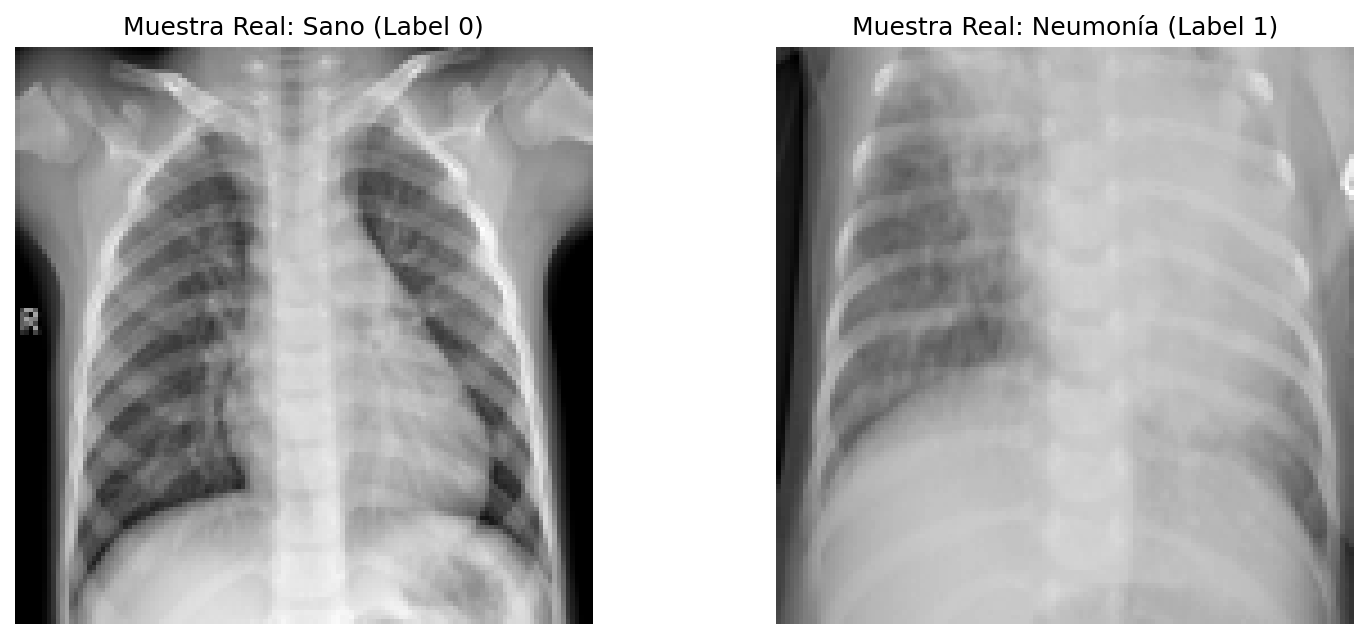
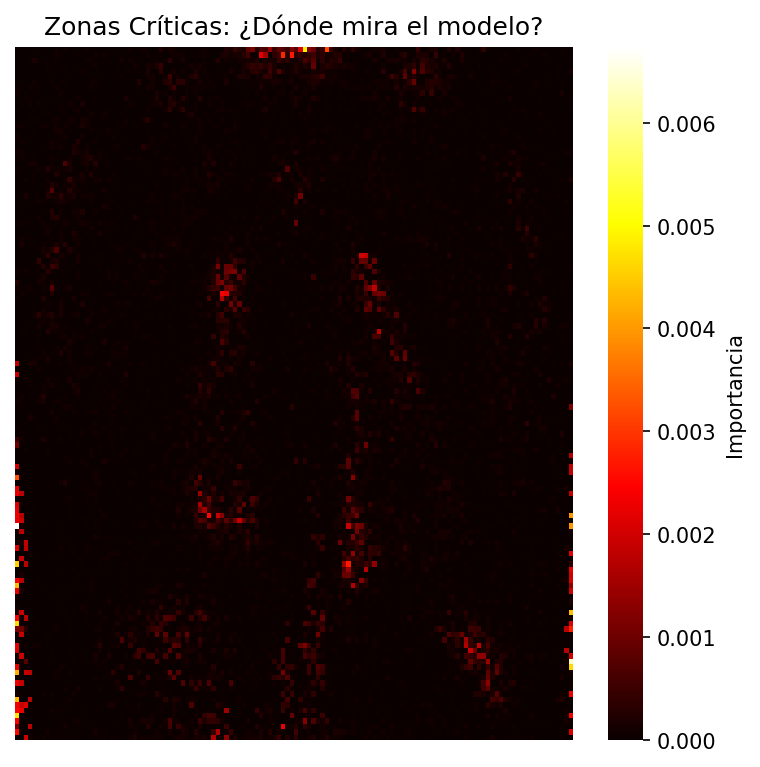
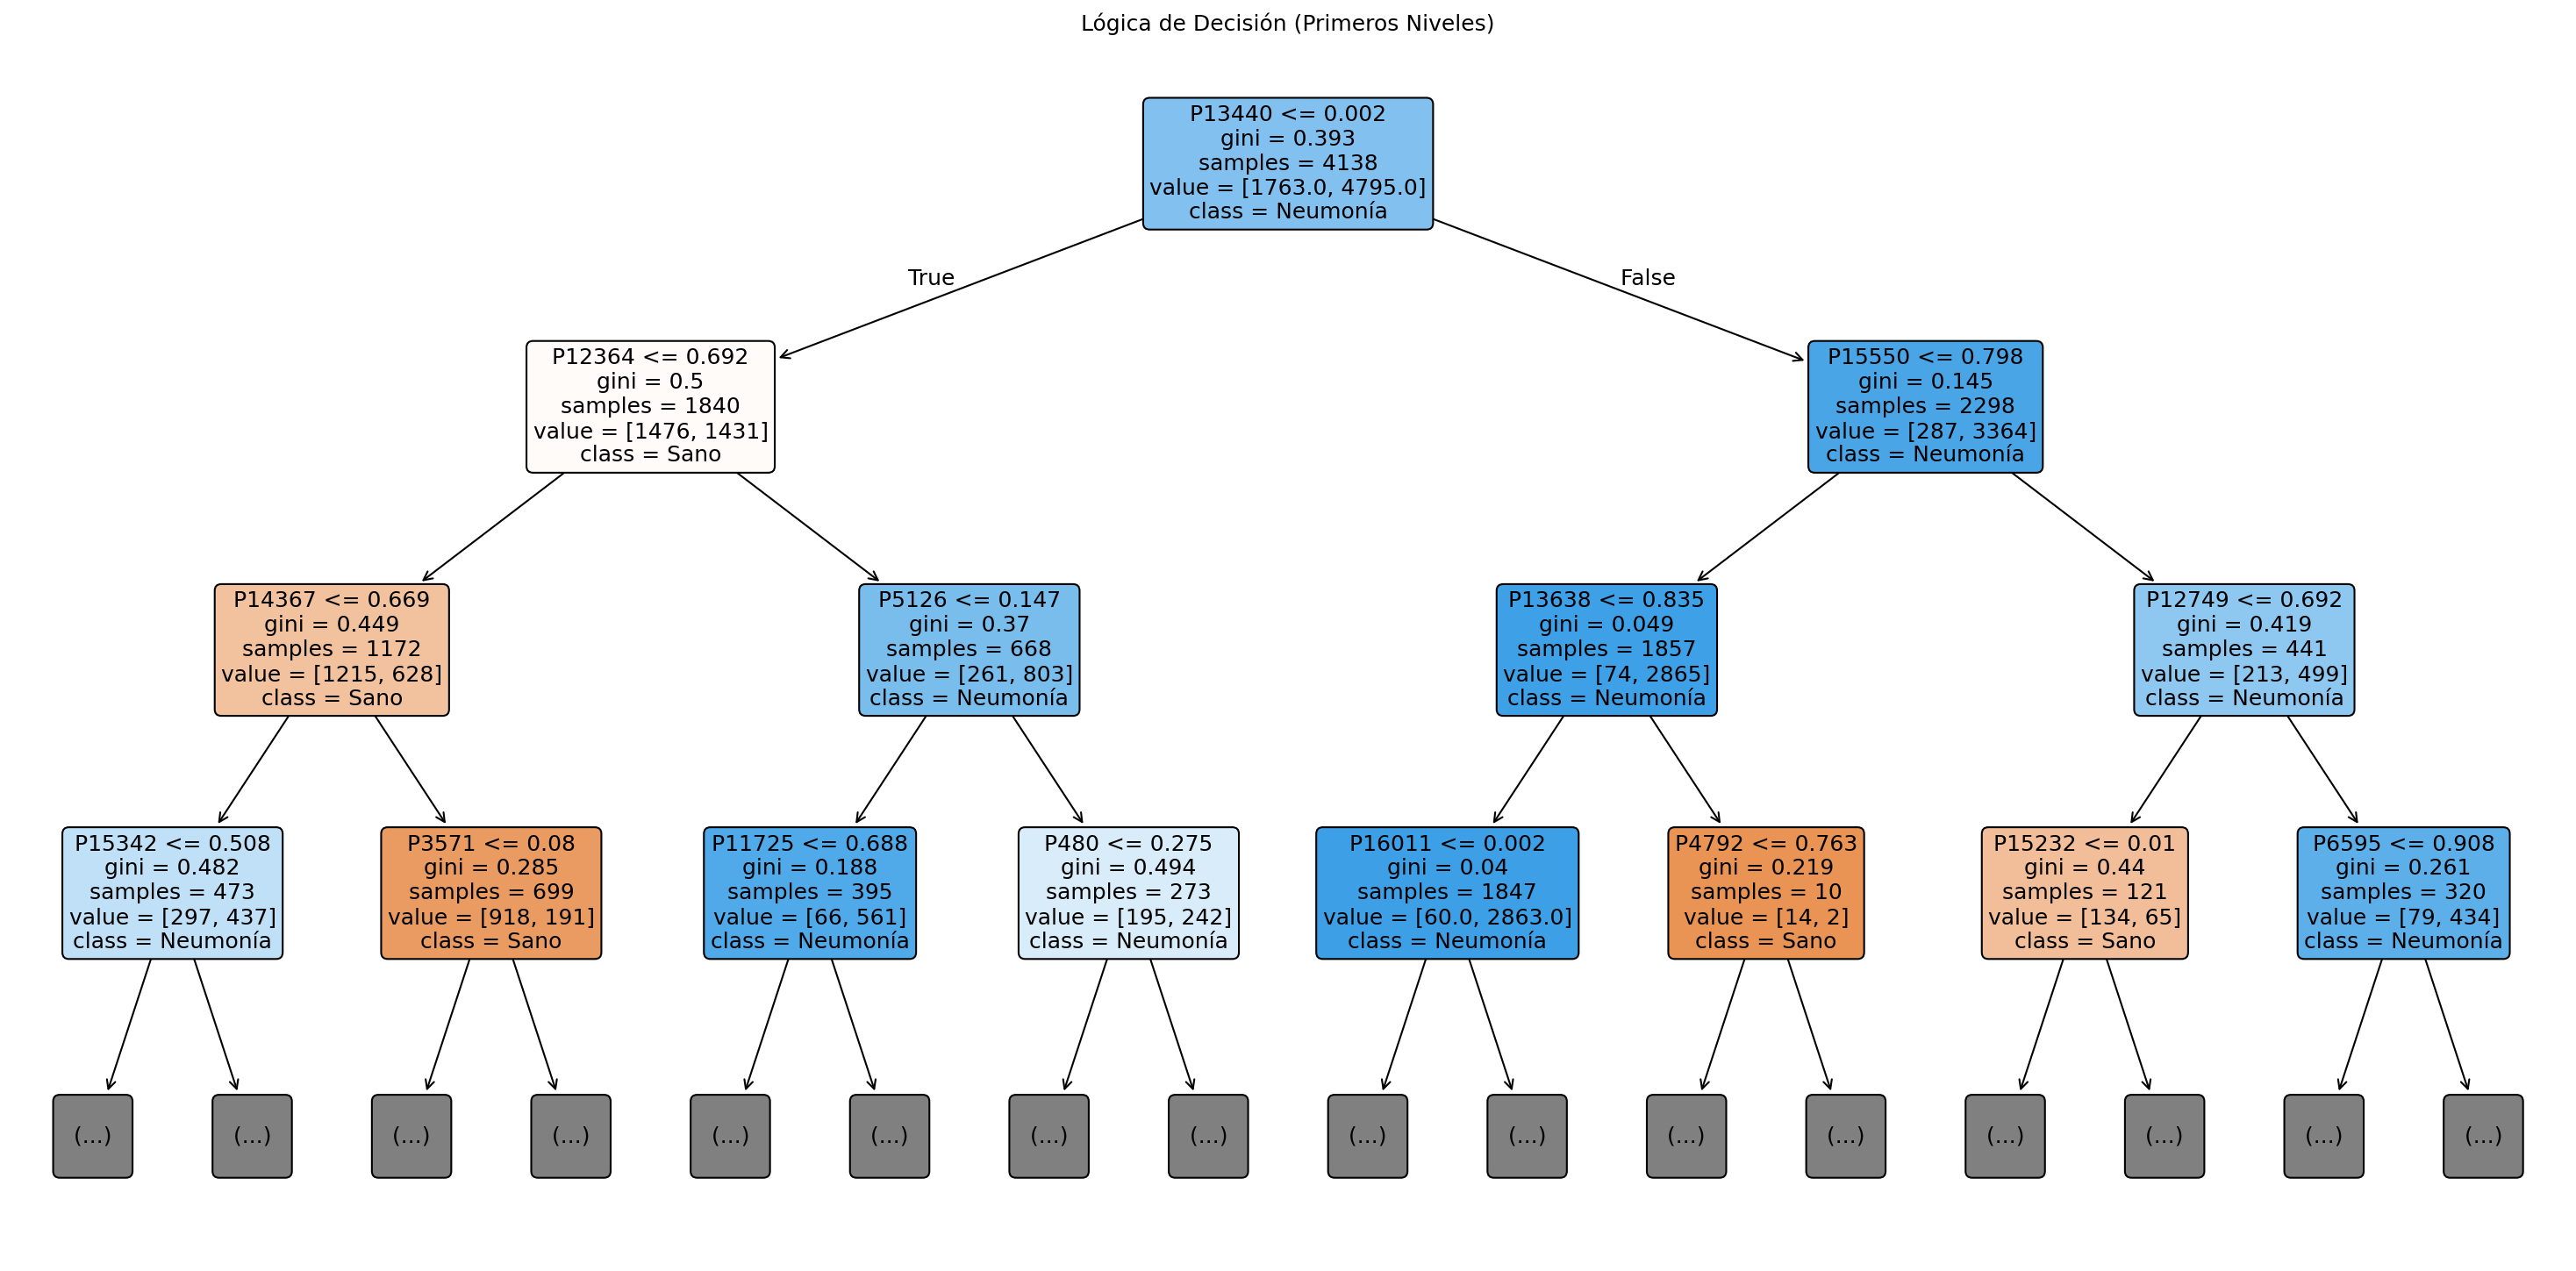

In [ ]:

#@title Visualización de Resultados { display-mode: "form" }
%%html
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Reporte de IA: Detección de Neumonía</title>
    <style>
        body { font-family: sans-serif; margin: 40px; color: #333; line-height: 1.6; }
        h1 { color: #2c3e50; border-bottom: 2px solid #eee; }
        h2 { color: #2980b9; margin-top: 40px; }
        .container { text-align: center; background: #f9f9f9; padding: 20px; border-radius: 10px; }
        img { max-width: 100%; height: auto; border: 1px solid #ddd; margin: 10px 0; }
        .stats { display: flex; justify-content: space-around; background: #2c3e50; color: white; padding: 15px; border-radius: 5px; }
    </style>
</head>
<body>
    <h1>Reporte de Interpretabilidad: Detección de Neumonía</h1>
  <li><b>Normalización:</b> Los datos fueron escalados al rango [0, 1] para asegurar estabilidad numérica y compatibilidad futura.</li>
    <div class="stats">
        <div><b>Bosque:</b> 100 árboles</div>
        <div><b>Entradas:</b> 128x128 píxeles</div>
        <div><b>Estado:</b> Entrenamiento Exitoso</div>
    </div>

    <h2>1. Reconstrucción de Imágenes Analizadas</h2>
    <p>Así es como se ven las imágenes originales después de ser procesadas por tu código:</p>
    <div class="container">
        <img src="...">
    </div>

    <h2>2. Mapa de Calor de Relevancia (Feature Importance)</h2>
    <p>Las zonas en amarillo/blanco son los píxeles que el modelo usa para diferenciar clases.</p>
    <div class="container">
        <img src="..." width="500">
    </div>

    <h2>3. Lógica del Árbol de Decisión</h2>
    <p>Muestra simplificada de los niveles superiores de un árbol del bosque:</p>
    <div class="container">
        <img src="...">
    </div>

    <h2>4. Conclusiones Técnicas</h2>
    <ul>
        <li><b>Profundidad:</b> El modelo explora relaciones complejas hasta 20 niveles.</li>
        <li><b>Invarianza:</b> Si se requirió normalización, dejando en rango desde 0 a 1</li>
        <li><b>Foco:</b> El modelo se concentra en las variaciones de intensidad dentro de la cavidad torácica.</li>
    </ul>
</body>
</html>
